# Yolov10: Real-Time End-to-End Object Detection

### Overview

YOLOv10, built on the UltralyticsPython package by researchers at Tsinghua University, introduces a new approach to real-time object detection, addressing both the post-processing and model architecture deficiencies found in previous YOLO versions. By eliminating non-maximum suppression (NMS) and optimizing various model components, YOLOv10 achieves state-of-the-art performance with significantly reduced computational overhead. Extensive experiments demonstrate its superior accuracy-latency trade-offs across multiple model scales.

<img src="https://github.com/ultralytics/docs/releases/download/0/yolov10-consistent-dual-assignment.avif" width="50%" height="50%" alt="YOLOv10">

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/yolov10/

### Overview

Real-time object detection aims to accurately predict object categories and positions in images with low latency. The YOLO series has been at the forefront of this research due to its balance between performance and efficiency. However, reliance on NMS and architectural inefficiencies have hindered optimal performance. ***YOLOv10 addresses these issues by introducing consistent dual assignments for NMS-free training and a holistic efficiency-accuracy driven model design strategy.***

#### Architecture
The architecture of YOLOv10 builds upon the strengths of previous YOLO models while introducing several key innovations. The model architecture consists of the following components:

1. Backbone: Responsible for feature extraction, the backbone in YOLOv10 uses an enhanced version of CSPNet (Cross Stage Partial Network) to improve gradient flow and reduce computational redundancy.
2. Neck: The neck is designed to aggregate features from different scales and passes them to the head. It includes PAN (Path Aggregation Network) layers for effective multiscale feature fusion.
3. One-to-Many Head: Generates multiple predictions per object during training to provide rich supervisory signals and improve learning accuracy.
4. One-to-One Head: Generates a single best prediction per object during inference to eliminate the need for NMS, thereby reducing latency and improving efficiency.


#### Key Features
1. NMS-Free Training: Utilizes consistent dual assignments to eliminate the need for NMS, reducing inference latency.
2. Holistic Model Design: Comprehensive optimization of various components from both efficiency and accuracy perspectives, including lightweight classification heads, spatial-channel decoupled down sampling, and rank-guided block design.
3. Enhanced Model Capabilities: Incorporates large-kernel convolutions and partial self-attention modules to improve performance without significant computational cost.

In [1]:
!nvidia-smi

Sat Nov 29 16:15:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 22%   40C    P8             28W /  250W |     631MiB /  11264MiB |     30%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download Test Data

In [1]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 4 persons, 1 bus, 40.5ms
Speed: 1.5ms preprocess, 40.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)


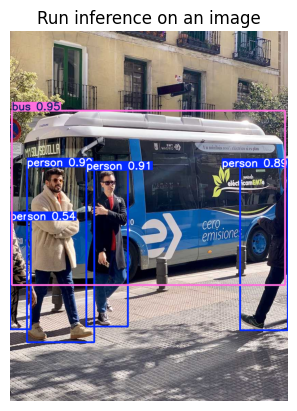

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("./temp_model/yolov10n.pt")

results = model("./temp_assets/bus.jpg")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()



image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 384x640 2 persons, 53.0ms
Speed: 1.4ms preprocess, 53.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


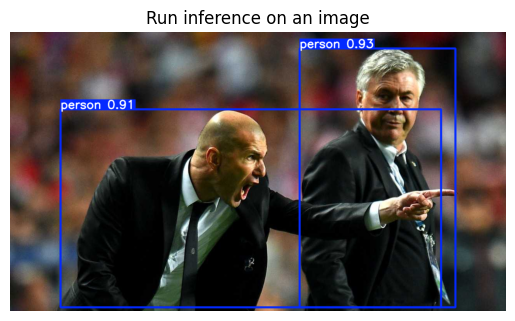

In [ ]:

results = model("./temp_assets/zidane.jpg")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()